# NeuralCodec-RPi - Benchmark Analysis

Comparison of traditional (Opus, Codec2) vs neural (EnCodec, SoundStream), speech codecs for low-bandwidth voice transmission on Raspberry Pi 4.

## Target Bandwidth

As we target low bandwidth networks in this project, this is a brief comparison between encoders on the target bitrates **3 kbps** and **6 Kbps**.

*  **3 kbps** (satellite Iridium, HF radio)
*  **6 kbps** (satellite, degraded 2G).

## Audio Dataset

For this benchmark we used the samples from LibriSpeech dev-clean, 16 kHz mono.

**https://www.openslr.org/12**

## 2. Mesures

to evaluate encoders performance on the rasbeprry PI, we tried to use both quality and computional metrics.

- PESQ (ITU-T P.862.2)
- Bitrate (kbps)
- RTF (Real-Time Factor)

### 2.1 PESQ (Perceptual Evaluation of Speech Quality)

PESQ tries to guess how a human would rate the quality. It was made for old phone codecs, so it is not perfect for new neural codecs. Neural codecs can sound better than their PESQ score shows.


## PESQ Table

| Score | Quality | Meaning |
|:---|:---|:---|
| 4.0 – 4.5 | Excellent | Sounds like the original, no problems |
| 3.5 – 3.9 | Good | Small differences, easy to listen |
| 3.0 – 3.4 | Fair | Some noise or distortion, still okay |
| 2.5 – 2.9 | Poor | Noticeable problems, needs effort to understand |
| 2.0 – 2.4 | Bad | Hard to understand, many errors |
| 1.0 – 1.9 | Very Bad | Cannot understand the speech |

### 2.2 Bitrate

Bitrate tells how much data the codec uses each second. It is measured in **kbps** (kilobits per second).

Lower bitrate means smaller files and less bandwidth. But too low means worse quality. We measure the real bitrate from the compressed file size, not just the target number.

$$
\text{Bitrate (kbps)} = \frac{\text{File Size (bits)}}{\text{Duration (seconds)} \times 1000}
$$

### 2.3 RTF (Real-Time Factor)

RTF is computional metric that mesures the encoding/decoding time relive to the audio length.

We used the RTF mesure to tell if the Raspberry Pi can process audio fast enough to perform a real time voice communication.

$$\text{RTF} = \frac{t_{\text{encode}} + t_{\text{decode}}}{d_{\text{audio}}}$$

- $\text{RTF} < 1$: good for real-time
- $\text{RTF} > 1$: bad

## 3. Setup

This notebook depend on the results file `results/results.csv`, so make sure to run `python benchmark/run.py` on the raspberry PI before executing this notebook to generate results file.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../benchmark/results/results.csv')
df

,codec_name,target_bitrate,real_bitrate,pesq,rtf_encode,rtf_decode
0,opus,6.0,6.464846,2.414972,0.006100,0.001564
1,opus,8.0,8.460068,3.288196,0.006849,0.001806
2,opus,12.0,12.694198,4.119486,0.010745,0.001791
3,opus,16.0,16.694881,4.398757,0.010790,0.001811
4,opus,32.0,32.603413,4.580898,0.011348,0.002049
5,opus,64.0,67.726962,4.601194,0.003838,0.002600
6,codec2,1.2,1.200000,1.637028,0.116322,0.001800
7,codec2,1.3,1.400000,1.746054,0.002120,0.001863
8,codec2,1.6,1.600000,1.797848,0.002249,0.001817
9,codec2,2.4,2.400000,1.900693,0.002127,0.001890


## 4. Quality vs Bitrate Comparison

In this section we compare each encodec bitrate vs its PESQ scored result with supported bitrates of the encodec.

It worth knowing that some encodecs support only specific bitrates for encoding/decoding.

The threshold we used are:

**Thresholds:**
- **PESQ ≥ 3.0**: good quality (ITU standard for voice communication)
- **PESQ ≥ 2.5**: intelligible (relevant for low-bandwidth constraints)

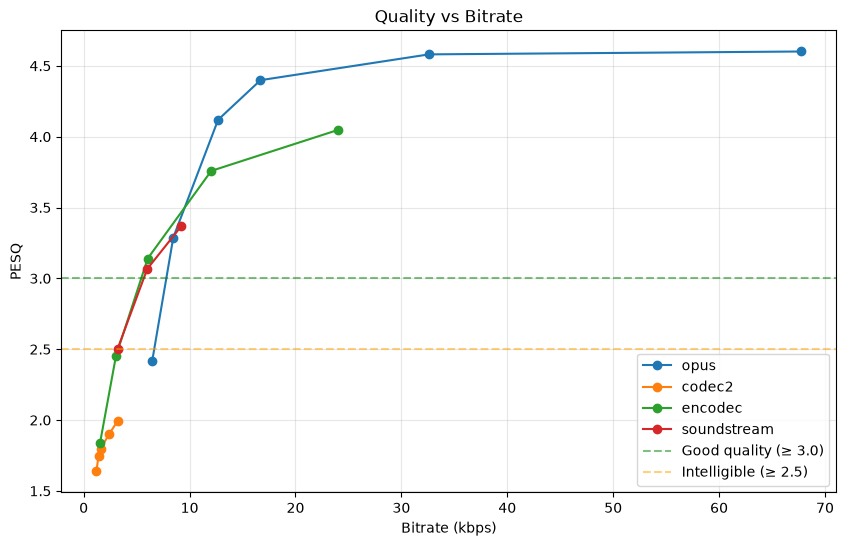

In [ ]:
fig, ax = plt.subplots()

for codec in df['codec_name'].unique():
    subset = df[df['codec_name'] == codec]
    ax.plot(subset['real_bitrate'], subset['pesq'], marker='o', label=codec)

ax.axhline(y=3.0, color='green', linestyle='--', alpha=0.5, label='Good quality (≥ 3.0)')
ax.axhline(y=2.5, color='orange', linestyle='--', alpha=0.5, label='Intelligible (≥ 2.5)')

ax.set_xlabel('Bitrate (kbps)')
ax.set_ylabel('PESQ')
ax.set_title('Quality vs Bitrate')
ax.legend()
ax.grid(alpha=0.3)
plt.show() 

## Quality comparison at target bitrates

Now to simplify the observation with our goal in this project, this is a comparison only on the bitrates that we target 3/6 kbps.

In [ ]:
targets = df[df['target_bitrate'].isin([3, 3.2, 6])]

pivot = targets.pivot_table(
    index='codec_name',
    columns='target_bitrate',
    values='pesq'
).round(2)

pivot

target_bitrate,3.0,3.2,6.0
codec_name,,,
codec2,NaN,1.99,NaN
encodec,2.45,NaN,3.14
opus,NaN,NaN,2.41
soundstream,NaN,2.50,3.07


### 4.1 Observations

* Opus: reaches acceptable PESQ quality (PESQ > 3.0) starting from ~ 8 kbps.
* Codec2: never exceeds PESQ 1.99 even at its maximum bitrate 3.2 kbps.
* Encodec: intelligable quality starting from 3 kbps (PESQ ~ 2.4), and good quality (3.14 PESQ) starting from 6 kbps.
* SoundStream: intelligible from 3.2 kbps (2.5 PESQ), and at 6 kbps output good quality of 3.0 PESQ.


**Key observation: Encodec and Soundstream performs well and thier PESQ results are simailar starting from 3 Kbps.**

## 5. Computational Cost (RTF)

RTF measures how fast each codec processes audio relative to the audio duration.
We measure encoding and decoding separately since in our Pi-to-Pi system, 
each Pi handles only one operation.

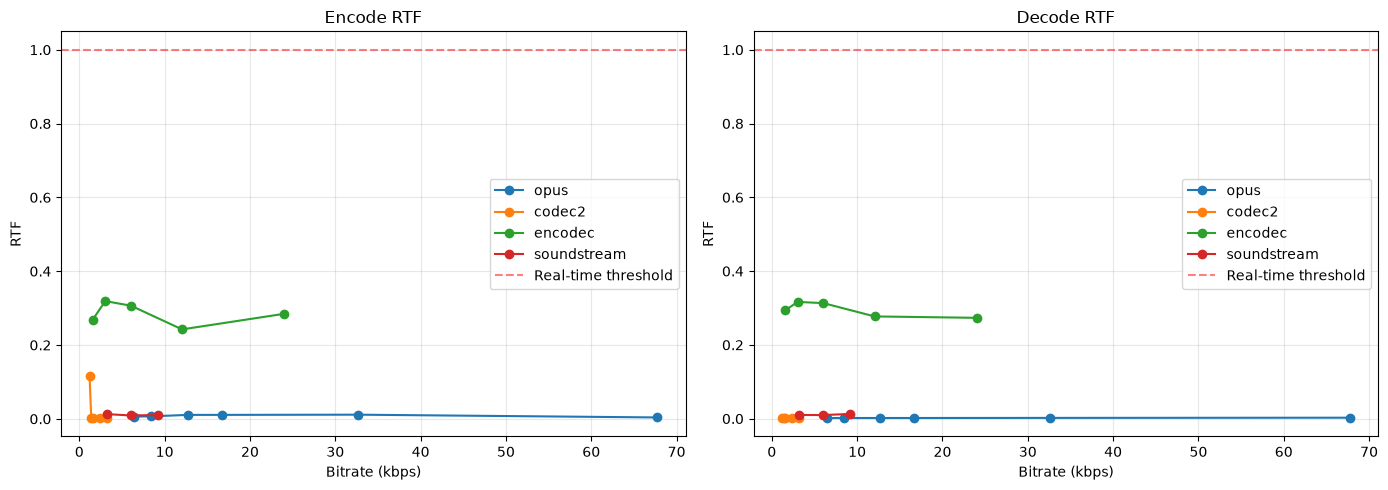

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Encode RTF
for codec in df['codec_name'].unique():
    subset = df[df['codec_name'] == codec]
    ax1.plot(subset['real_bitrate'], subset['rtf_encode'], marker='o', label=codec)

ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Real-time threshold')
ax1.set_xlabel('Bitrate (kbps)')
ax1.set_ylabel('RTF')
ax1.set_title('Encode RTF')
ax1.legend()
ax1.grid(alpha=0.3)

# Decode RTF
for codec in df['codec_name'].unique():
    subset = df[df['codec_name'] == codec]
    ax2.plot(subset['real_bitrate'], subset['rtf_decode'], marker='o', label=codec)

ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Real-time threshold')
ax2.set_xlabel('Bitrate (kbps)')
ax2.set_ylabel('RTF')
ax2.set_title('Decode RTF')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.1 Observations

...

## 6. Conclusion
